Using 989 stars


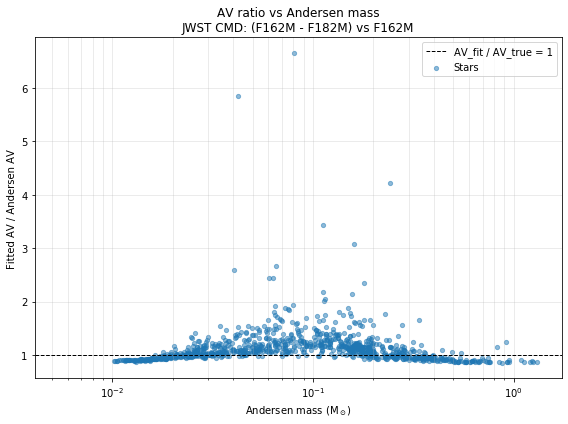

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path to your with-truth CSV
csv_path = "./fit_results_jwst_cmd_F162MminusF182M_vs_F162M_with_truth.csv"

df = pd.read_csv(csv_path)

# Basic cleaning
d = df.copy()
d = d[
    np.isfinite(d["true_mass"]) &
    np.isfinite(d["true_AV"]) &
    np.isfinite(d["best_AV"]) &
    (d["true_mass"] > 0) &
    (d["true_AV"] > 0) &
    (d["best_AV"] > 0)
].copy()

# Ratio: my fitted AV / Andersen AV
d["AV_ratio"] = d["best_AV"] / d["true_AV"]

print(f"Using {len(d)} stars")

plt.figure(figsize=(8, 6))
plt.scatter(
    d["true_mass"],
    d["AV_ratio"],
    s=18,
    alpha=0.5,
    label="Stars"
)

plt.axhline(1.0, color="k", linestyle="--", linewidth=1, label="AV_fit / AV_true = 1")

plt.xscale("log")
plt.xlabel("Andersen mass (M$_\\odot$)")
plt.ylabel("Fitted AV / Andersen AV")
plt.title("AV ratio vs Andersen mass\nJWST CMD: (F162M - F182M) vs F162M")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()